# Pattern Recognition 3 - Points and Neighbourhoods

**Objectives**:

* Detect points of interest in an image
* Extract neighbourhood descriptors
* Use descriptors for clustering and matching

## Points of interest

In the previous labs, we have analyzed the images either using "object descriptors" (area, eccentricity, moments of segmented object) or "image descriptors" (based on all the pixels of the image). Another way of approaching an image analysis problem is to first look for "interesting points".

What makes a point *interesting* will highly depend on the application. Common examples are **corners**, or **local extrema**.

Starting from the `mitosis.bmp` image, find or create a **point detector** that will detect the nuclei of the cells.

> *Hint: it may be easier to do so in a different color space...*

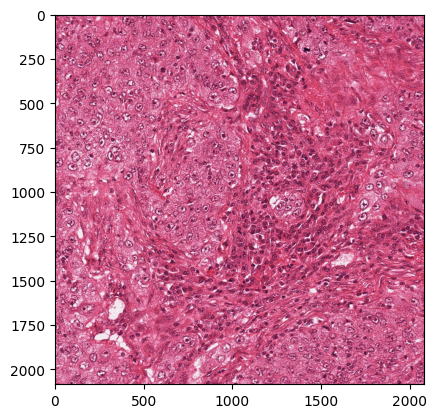

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread

im = imread('mitosis.bmp')
plt.figure()
plt.imshow(im)
plt.show()

<Figure size 640x480 with 0 Axes>

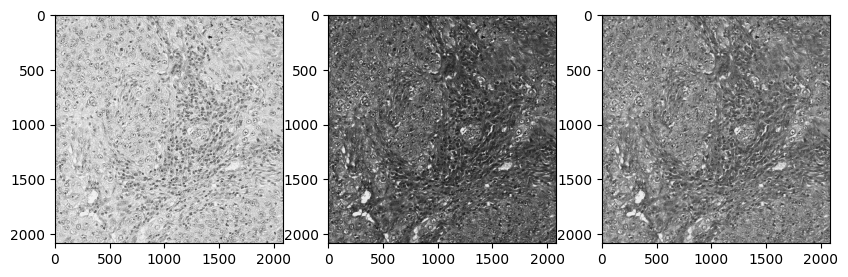

In [2]:
# explore possibilities with color channels
plt.gray()
plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(im[:, :, 0])
plt.subplot(132)
plt.imshow(im[:, :, 1])
plt.subplot(133)
plt.imshow(im[:, :, 2])
plt.show()

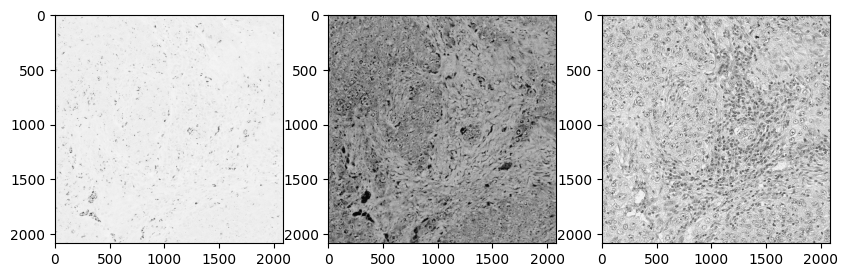

In [3]:
from skimage.color import rgb2hsv
hsv = rgb2hsv(im) # crop image with im[500:1000, 500:1000, :]
plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(hsv[:, :, 0])
plt.subplot(132)
plt.imshow(hsv[:, :, 1])
plt.subplot(133)
plt.imshow(hsv[:, :, 2])
plt.show()

We will use the value channel from the HSV (or red channel from RGB). It will help to segment the image and to find the nuclei of the cells.

Now we can find blobs in the image. Blobs are bright on dark or dark on bright regions in an image

(7004, 3)


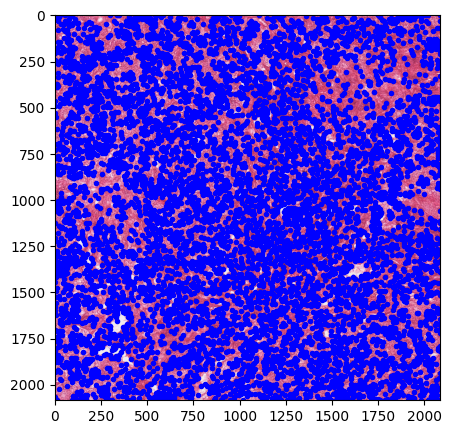

In [4]:
from skimage.feature import blob_log

# find blobs in the image
blobs = blob_log(1-hsv[:,:,2], min_sigma = 4, max_sigma=10, threshold=0.1)
print(blobs.shape)

plt.figure(figsize=(10, 5))
plt.imshow(im)
plt.plot(blobs[:, 1], blobs[:, 0], 'b.', alpha=1)
plt.show()

Local peaks

(2495, 2)


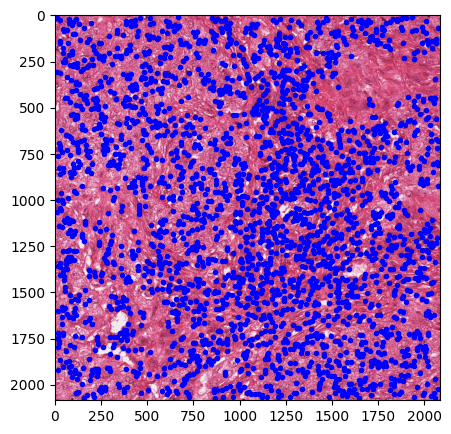

In [5]:
# local peak detection
from skimage.feature import peak_local_max

plm = peak_local_max(1-hsv[:,:,2], min_distance=10, threshold_rel=0.7)
print(plm.shape)
plt.figure(figsize=(10, 5))
plt.imshow(im)
plt.plot(plm[:, 1], plm[:, 0], 'b.', alpha=1)
plt.show()

## Descriptors

The goal of *descriptors* is to represent the region surrounding the point of interest in a way that allow our algorithm to best perform its task. For instance, the BRIEF descriptor will compare pairs of pixels in the given neighbourhood and create a binary descriptor representing the result of all these comparison. This kind of descriptor will tend to create a unique signature in a grayscale image, and is very useful for applications such as matching for stereo-vision or for video tracking.

Other types of descriptors can be based on the texture (for instance with local Fourier transforms) or on local histograms.

* Using the points detected before, **extract neighbourhood patches** and **compute the concatenated color histogram** as a descriptor (meaning a 256+256+256 = size 768 vector, with the first 256 values corresponding to the R histogram, etc...).
* Use the [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) class from `scikit-learn` to cluster the points of interest depending on their descriptor. Can you identify clusters representing the type of tissue of the cell?

In [6]:
from sklearn.cluster import KMeans

def compute_histogram(patch):
    rgb_histogram = np.zeros((768,))
    
    for v in range(256):
        rgb_histogram[v] = np.sum(patch[:, :, 0] == v)
        rgb_histogram[v + 256] = np.sum(patch[:, :, 1] == v)
        rgb_histogram[v + 512] = np.sum(patch[:, :, 2] == v)
    
    return rgb_histogram

def extract_descriptors(im, coords, neighbourhood_size=15):
    ## compute histogram and compile everything in a "descriptor matrix"
    descriptors = []
    for row,col in coords:
        region = im[row-neighbourhood_size//2:row+neighbourhood_size//2,col-neighbourhood_size//2:col+neighbourhood_size//2]
        descriptors.append(compute_histogram(region))

    return np.array(descriptors)

descriptors = extract_descriptors(im, plm)
print(descriptors.shape)

(2495, 768)


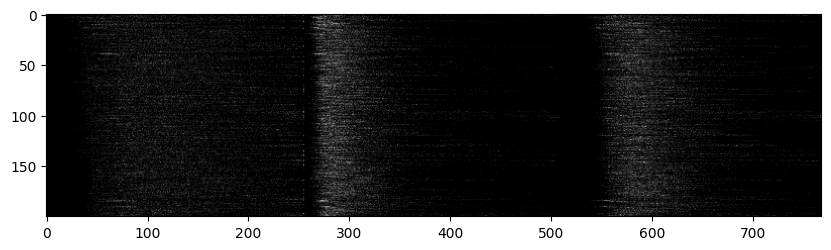

In [7]:
plt.figure(figsize=(10, 5))
plt.imshow(descriptors[:200])

In [8]:
km = KMeans(n_clusters=2, random_state=0) #we want 2 clusters for the cells and the other region
km.fit(descriptors)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",0
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 768)","

1401 1094


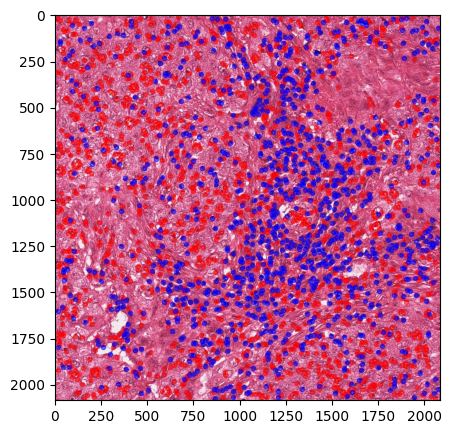

In [9]:
clusters = km.predict(descriptors)
print((clusters == 0).sum(), (clusters == 1).sum())
plt.figure(figsize=(10, 5))
plt.imshow(im)
plt.plot(plm[clusters == 0, 1], plm[clusters == 0, 0], 'r.', alpha=0.5)
plt.plot(plm[clusters == 1, 1], plm[clusters == 1, 0], 'b.', alpha=0.5)
plt.show()

* Apply the same point detection and descriptors on the `mitosis2.bmp` image, and use the already trained KMeans to predict the clusters of the points in the new image.

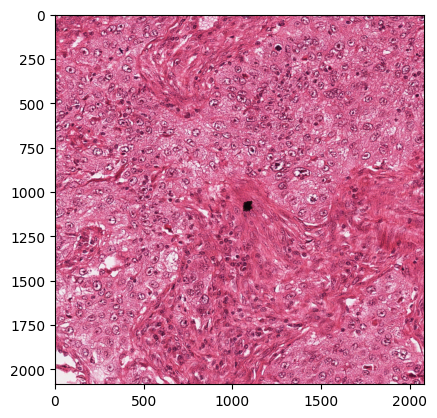

In [10]:
im2 = imread('mitosis2.bmp')
plt.figure()
plt.imshow(im2)
plt.show()

In [11]:
hsv2 = rgb2hsv(im2)
plm2 = peak_local_max(1-hsv2[:,:,2], min_distance=10, threshold_rel=0.5)
print(plm2.shape)
descriptors2 = extract_descriptors(im2, plm2)
print(descriptors.shape)

(4691, 2)
(2495, 768)


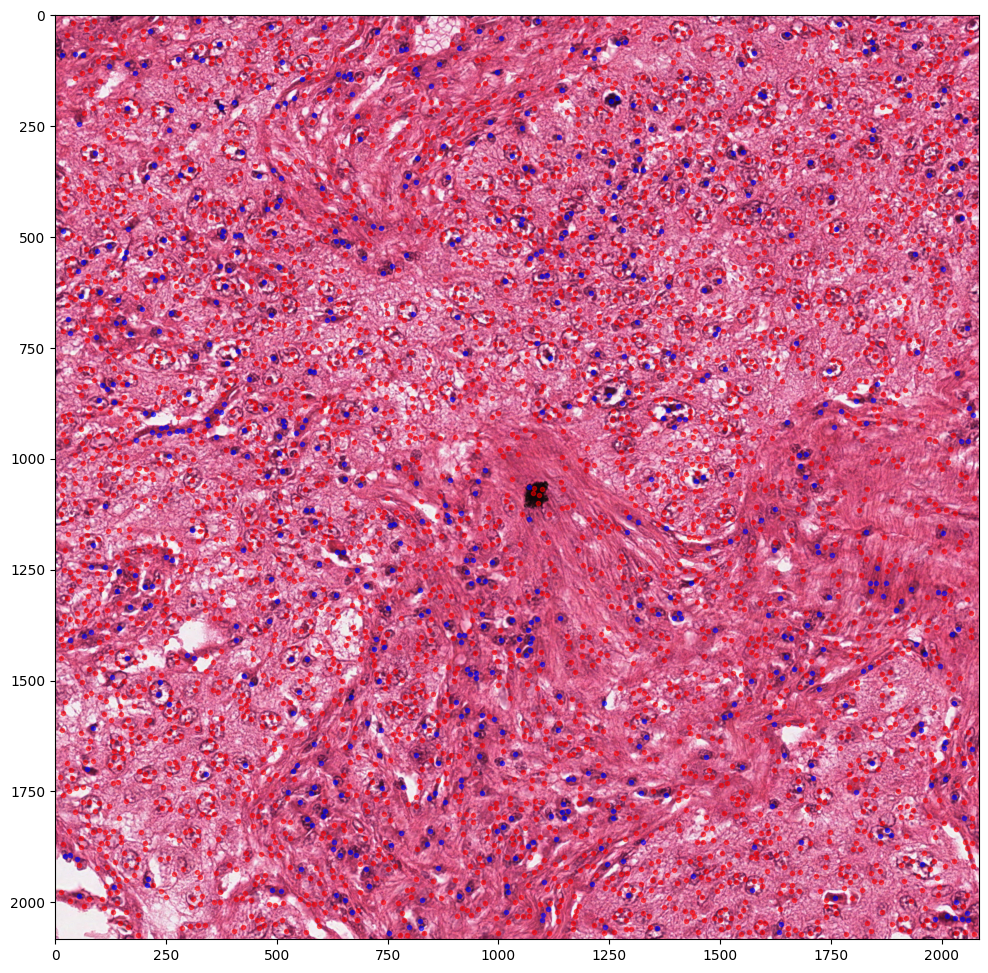

In [12]:
clusters2 = km.predict(descriptors2)
plt.figure(figsize=(12, 12))
plt.imshow(im2)
plt.plot(plm2[clusters2 == 0, 1], plm2[clusters2 == 0, 0], 'r.', alpha=0.5)
plt.plot(plm2[clusters2 == 1, 1], plm2[clusters2 == 1, 0], 'b.', alpha=0.5)
plt.show()